# The Z-Distribution <hr style="border:3.5px solid #ff56bbff"></hr> 

<b>Marian Kristel M. Banquisio</b>
<br>BSECE-3A
<br>February 28, 2026

In [2]:
#import and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
#Load Dataset
df = pd.read_csv(r"C:\Users\Admin\Downloads\dataset\transformer-voltage.csv",
                 index_col = 'Sample',
                 delimiter = ",")
df

,Voltage
Sample,
1,117.0
2,118.3
3,119.5
4,119.5
5,119.6
6,119.6
7,119.7
8,119.7
9,119.7


In [4]:
#Summary of Dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 1 to 30
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Voltage  30 non-null     float64
dtypes: float64(1)
memory usage: 372.0 bytes


In [5]:
#Summary of Statistics
df.describe()

,Voltage
count,30.000000
mean,120.290000
std,1.243285
min,117.000000
25%,119.700000
50%,120.100000
75%,120.500000
max,123.800000


In [6]:
#Z-Critical for Two-tailed Test
alpha = 0.01
z_critical = stats.norm.ppf(1-alpha/2)
z_critical

np.float64(2.5758293035489004)

In [7]:
# Confidence Interval
pop_std = 5

ci_lower, ci_upper = stats.norm.interval(
    confidence = 0.95,
    loc = df['Voltage'].mean(),
    scale = pop_std/np.sqrt(df['Voltage'].count())
)   
print(f"Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}]")

Confidence Interval: [118.50, 122.08]


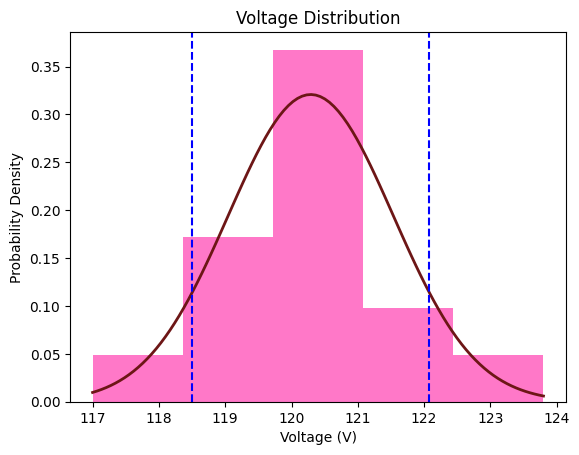

In [10]:
# Voltage Distribution
mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

# x-axis
x_min = df['Voltage'].min()
x_max = df['Voltage'].max()

# Normal Distribution Plot
x = np.linspace(x_min, x_max, 100)
p = stats.norm.pdf(x, mean, std)

plt.plot(x, p,
         linewidth=2,
         color='#6D1616')

# Histogram
plt.hist(df['Voltage'],
         bins=5,
         density=True,
         alpha=0.8,
         color='#ff56bbff')

plt.title('Voltage Distribution')
plt.ylabel('Probability Density')
plt.xlabel('Voltage (V)')

# Confidence Interval
plt.axvline(x=ci_lower,
            color='blue',
            linestyle='--')

plt.axvline(x=ci_upper,
            color='blue',
            linestyle='--')

plt.show()